In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
import faiss, time
from scipy.spatial.distance import jensenshannon

In [6]:
# The SIFT dataset vectors are stored in .fvecs format.
# Each vector entry starts with an int32 dimension prefix followed by that many float32 components.

def read_ivecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    return data[:, 1:]

def read_fvecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    # reinterpret everything except first column as float32
    vectors = data[:, 1:].view(np.float32)

    return vectors

BASE = "/content/sift/sift_base.fvecs"
QUERY = "/content/sift/sift_query.fvecs"
TRUTH = "/content/sift/sift_groundtruth.ivecs"

base_vectors = read_fvecs(BASE)
query_vectors = read_fvecs(QUERY)
truth_vectors = read_ivecs(TRUTH)

print(f"Dimensions of base: {base_vectors.shape}    Type: {base_vectors.dtype}")
print(f"Dimensions of query: {query_vectors.shape}    Type: {query_vectors.dtype}")
print(f"Dimensions of truth: {truth_vectors.shape}    Type: {truth_vectors.dtype}")

Dimensions of base: (1000000, 128)    Type: float32
Dimensions of query: (10000, 128)    Type: float32
Dimensions of truth: (10000, 100)    Type: int32


In [7]:
def base_clusters(vectors, k, seed=42):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=1024,
        max_iter=100
    )
    return kmeans.fit_predict(vectors)

def generate_continuous_from_labels(labels, k, corr_strength=1.0, seed=42):
    rng = np.random.default_rng(seed)

    # 1. Map labels to a 0-200 signal
    # We spread k clusters across the 0-200 range
    label_means = np.linspace(20, 180, k)
    signal = label_means[labels]

    # 2. handle Negative Correlation (-1.0)
    # If negative, we invert the signal: high clusters get low values
    if corr_strength < 0:
        signal = 200 - signal

    # 3. Blend with Noise
    # This is equivalent to your 'add_noise' but on a continuous scale
    abs_corr = abs(corr_strength)
    random_noise = rng.uniform(0, 200, size=len(labels))

    attr = (abs_corr * signal) + ((1 - abs_corr) * random_noise)

    # Add small local jitter so points in same cluster aren't identical
    attr += rng.normal(0, 5, size=len(labels))

    return np.clip(attr, 0, 200)

In [8]:
# === STATISTICS ===
n, d = base_vectors.shape
ids = np.arange(n)

k_struct = 80
kmeans = MiniBatchKMeans(n_clusters=k_struct, random_state=42, n_init="auto").fit(base_vectors)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
cluster_to_indices = {c: np.where(labels == c)[0] for c in range(k_struct)}

# --- EXECUTION ---
attr_pos = generate_continuous_from_labels(labels, k_struct, corr_strength=0.7)
attr_neg = generate_continuous_from_labels(labels, k_struct, corr_strength=-0.7)
attr_rand = generate_continuous_from_labels(labels, k_struct, corr_strength=0.0)

In [9]:
# === HELPER FUNCTIONS ===
def build_cdf(attr, bins=100):
    hist, edges = np.histogram(attr, bins=bins, density=True)
    cdf = np.cumsum(hist)
    cdf = cdf / cdf[-1]
    return edges, cdf

def get_p_global(edges, cdf, threshold):
    idx = np.searchsorted(edges, threshold)
    if idx >= len(cdf): return 1.0
    return cdf[idx]

def _nearest_clusters(q, centroids, top_L=5):
    distances = np.linalg.norm(centroids - q, axis=1)
    return np.argsort(distances)[:top_L]

def _compute_ratio(vectors, value):
    return sum(evaluate_predicate(v, value) for v in vectors) / len(vectors)

def evaluate_predicate(v, value):
    return v <= value

In [10]:
def precompute_attribute_statistics(attr_array, cluster_to_indices):
    # Precompute the global CDF once
    attr_sorted = np.sort(attr_array)
    na = len(attr_sorted)

    # Store attributes per cluster
    cluster_attrs_sorted = {}
    cluster_sizes = {}

    for c, idx in cluster_to_indices.items():
        vals = np.sort(attr_array[idx])
        cluster_attrs_sorted[c] = vals
        cluster_sizes[c] = len(vals)

    return attr_sorted, na, cluster_attrs_sorted, cluster_sizes


In [11]:
# Precompute statistics for all correlation types and store them in a dictionary
precomputed_stats = {}

attr_types = {'Positive': attr_pos, 'Negative': attr_neg, 'Random': attr_rand}

for attr_name, attr_array in attr_types.items():
   precomputed_stats[attr_name] = precompute_attribute_statistics(attr_array, cluster_to_indices)

In [12]:
def precompute_nearest_clusters(query_vectors, centroids, top_L=7):

    Q = query_vectors
    C = centroids

    q_norm = np.sum(Q**2, axis=1, keepdims=True)
    c_norm = np.sum(C**2, axis=1)

    # BLAS-accelerated matrix multiplication
    dist_matrix = q_norm + c_norm - 2 * Q @ C.T

    nearest_clusters = np.argpartition(dist_matrix, top_L, axis=1)[:, :top_L]

    return nearest_clusters

nearest_clusters = precompute_nearest_clusters(query_vectors, centroids, top_L=7)

In [52]:
def query_corr(i, attr, precomp_stats):
      attr_val = attr[i]

      # lookup precomputed clusters
      neighbor_ids = nearest_clusters[i]

      count = 0
      total = 0

      attr_sorted, na, cluster_attrs_sorted, cluster_sizes = precomp_stats

      for c in neighbor_ids:
          arr = cluster_attrs_sorted[c]
          k = np.searchsorted(arr, attr_val)
          count += k
          total += len(arr)

      p_q = count / total

      # global CDF lookup
      p_global = np.searchsorted(attr_sorted, attr_val) / na

      eps = 1e-10
      p_dist = np.clip([p_q, 1 - p_q], eps, 1 - eps)
      q_dist = np.clip([p_global, 1 - p_global], eps, 1 - eps)

      js_div = jensenshannon(p_dist, q_dist)

      return {
          "js": js_div,
          "dir": p_q - p_global,
          "p_q": p_q,
          "p_g": p_global
      }

In [51]:
def analyze_sift_correlation(query_vectors, attr, precomp_stats):
    results = []
    for i in range(len(query_vectors)):
        results.append(query_corr(i, attr, precomp_stats))
    return results

In [14]:
res_pos = analyze_sift_correlation(query_vectors, attr_pos, precomputed_stats['Positive'])
res_neg = analyze_sift_correlation(query_vectors, attr_neg, precomputed_stats['Negative'])
res_rand = analyze_sift_correlation(query_vectors, attr_rand, precomputed_stats['Random'])

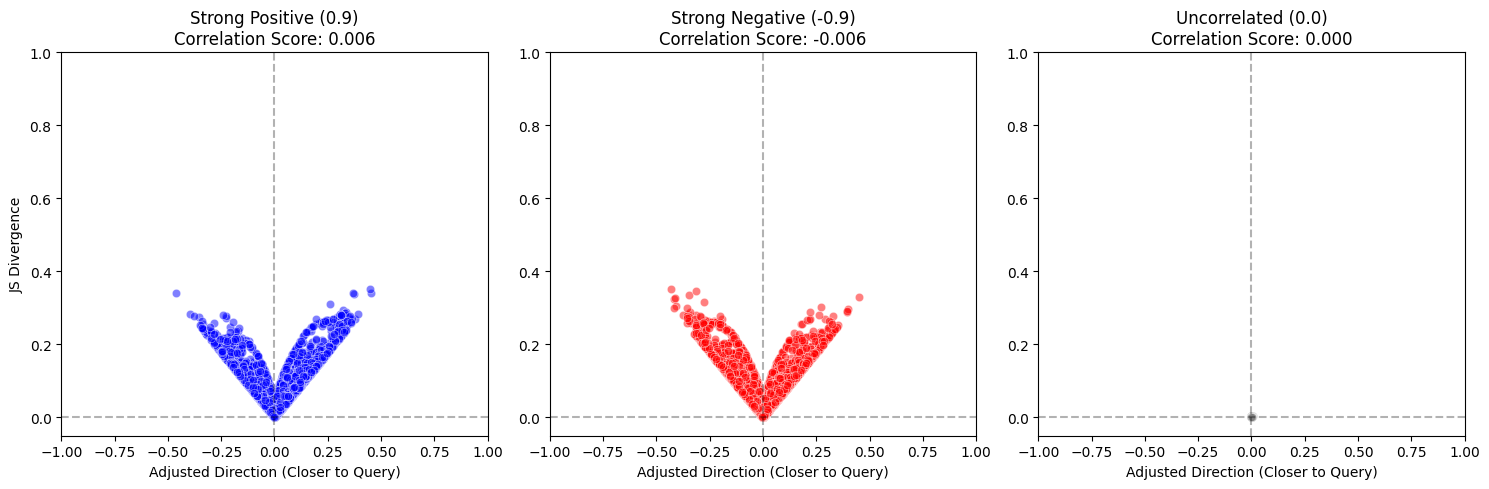

In [15]:
def plot_correlation_summary(res_pos, res_neg, res_rand):
    plt.figure(figsize=(15, 5))

    configs = [
        (res_pos, "Strong Positive (0.9)", "blue"),
        (res_neg, "Strong Negative (-0.9)", "red"),
        (res_rand, "Uncorrelated (0.0)", "gray")
    ]

    for i, (res, title, color) in enumerate(configs):
        js_vals = [r['js'] for r in res]
        dir_vals = [r['dir'] for r in res]

        # Score = Average of (JS * Sign of Adjusted Direction)
        # This prevents division by zero and correctly signs the correlation
        scores = [r['js'] * np.sign(r['dir']) for r in res]
        final_score = np.mean(scores)

        plt.subplot(1, 3, i+1)
        plt.scatter(dir_vals, js_vals, alpha=0.5, c=color, edgecolors='white', linewidth=0.5)

        # Quadrant lines
        plt.axvline(0, color='black', linestyle='--', alpha=0.3)
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)

        plt.ylim(-0.05, 1.0) # JS Divergence base-e can go up to ~0.83
        plt.xlim(-1, 1)
        plt.title(f"{title}\nCorrelation Score: {final_score:.3f}")
        plt.xlabel("Adjusted Direction (Closer to Query)")
        if i == 0: plt.ylabel("JS Divergence")

    plt.tight_layout()
    plt.show()

plot_correlation_summary(res_pos, res_neg, res_rand)

## Now we are going to start with the experiments
i.e. evaluate if our correlation metric actually influences better planning

In [16]:
def predicate_less_equal(attr, val):
    return attr <= val

def predicate_greater(attr, val):
    return attr > val

def predicate_range(attr, bounds):
    low, high = bounds
    return (attr >= low) & (attr <= high)

In [17]:
# Create a standard HNSW index (what ACORN builds upon)
global_index = faiss.IndexHNSWFlat(d, 32)
global_index.add(base_vectors)

In [24]:
# Define the Range Predicate
target_range = (50, 100)

In [47]:
def post_filter_search(index, query_vectors, attr, query_ranges, k=100, overfetch=10):
    start_time = time.time()
    D, I = index.search(query_vectors, k * overfetch)
    final_indices = []
    for i, row in enumerate(I):
        mask = predicate_range(attr[row], query_ranges[i])
        filtered_row = row[mask]
        res = filtered_row[:k]
        if len(res) < k:
            res = np.concatenate([res, np.full(k - len(res), -1, dtype='int64')])
        final_indices.append(res)
    duration = time.time() - start_time
    return np.array(final_indices), duration

def inline_filter_search(index, query_vectors, attr, query_ranges, k=100, overfetch=10):
    start_time = time.time()
    D, I = index.search(query_vectors, k * overfetch)
    final = []
    for i, row in enumerate(I):
        mask = predicate_range(attr[row], query_ranges[i])
        filtered = row[mask]
        res = filtered[:k]
        if len(res) < k:
            res = np.concatenate([res, np.full(k - len(res), -1, dtype='int64')])
        final.append(res)
    duration = time.time() - start_time
    return np.array(final), duration

def bucketed_pre_filter_search(query_vectors, query_ranges, bucket_size, bucketed_indexes, k=100):
    start_time = time.time()
    nq = query_vectors.shape[0]
    final_indices = np.full((nq, k), -1, dtype='int64')

    for i in range(nq):
        low, high = query_ranges[i]
        start_bucket = (int(low) // bucket_size) * bucket_size
        end_bucket = (int(high) // bucket_size) * bucket_size

        candidate_ids = []
        candidate_dists = []

        for s in range(start_bucket, end_bucket + bucket_size, bucket_size):
            bucket_key = (s, s + bucket_size)
            if bucket_key in bucketed_indexes:
                entry = bucketed_indexes[bucket_key]
                idx = entry['index']
                global_mapping = entry['ids']

                D, I_local = idx.search(query_vectors[i:i+1], min(k, idx.ntotal))

                valid_mask = I_local[0] != -1
                local_ids = global_mapping[I_local[0][valid_mask]]

                candidate_ids.append(local_ids)
                candidate_dists.append(D[0][valid_mask])

        if not candidate_ids:
            continue

        all_ids = np.concatenate(candidate_ids)
        all_dists = np.concatenate(candidate_dists)

        top_k_idx = np.argsort(all_dists)[:k]
        final_indices[i, :len(top_k_idx)] = all_ids[top_k_idx]

    duration = time.time() - start_time
    return final_indices, duration

In [35]:
bucket_size = 10
bucketed_indexes = {}
for attr_name, attr in attr_types.items():
    max_attr = int(attr.max())

    buckets = [(i, i + bucket_size) for i in range(0, max_attr, bucket_size)]

    bucket_indexes = {}
    for s, e in buckets:
      mask = (attr >= s) & (attr <= e)
      if mask.sum() == 0:
        continue

      filtered_ids = np.where(mask)[0]
      filtered_vectors = base_vectors[mask]

      index = faiss.IndexHNSWFlat(d, 32)
      index.add(filtered_vectors)

      bucket_indexes[(s, e)] = {
          "index": index,
          "ids": filtered_ids
      }
      bucketed_indexes[attr_name] = bucket_indexes

In [36]:
def random_ranges(attr, num_ranges=50):
    min_a, max_a = attr.min(), attr.max()
    ranges = []

    for _ in range(num_ranges):
        a = np.random.randint(min_a, max_a)
        b = np.random.randint(a, max_a)
        ranges.append((a, b))

    return ranges

In [43]:
def compute_ground_truth(data, query_vectors, attr, query_ranges, k=100):
    nq = query_vectors.shape[0]
    d = data.shape[1]
    truth_matrix = np.full((nq, k), -1, dtype='int64')

    for i in range(nq):
        # Use the predicate_range function
        mask = predicate_range(attr, query_ranges[i])
        valid_ids = np.where(mask)[0]

        if len(valid_ids) == 0:
            continue

        filtered_data = data[valid_ids]
        exact_index = faiss.IndexFlatL2(d)
        exact_index.add(filtered_data)

        _, local_indices = exact_index.search(query_vectors[i:i+1], min(k, len(valid_ids)))
        num_found = local_indices.shape[1]
        truth_matrix[i, :num_found] = valid_ids[local_indices[0]]

    return truth_matrix

def evaluate_strategy(name, search_func, query_vectors, truth_matrix):
    # Helper to keep consistent evaluation logic
    I, time_taken = search_func()
    nq = len(query_vectors)
    k = truth_matrix.shape[1]
    recalls = []
    for i in range(nq):
        pred = set(I[i][I[i] != -1])
        true = set(truth_matrix[i][truth_matrix[i] != -1])
        if len(true) > 0: recalls.append(len(pred & true) / len(true))
        else: recalls.append(1.0 if len(pred) == 0 else 0.0)
    avg_recall = np.mean(recalls)
    qps = nq / time_taken if time_taken > 0 else 0
    return avg_recall, qps, time_taken

In [32]:
indexes = {}
id_mappings = {} # Store mappings per attribute

for attr_name, current_attr in attr_types.items():
    mask = predicate_range(current_attr, target_range)
    valid_ids = np.where(mask)[0]
    filtered_vectors = base_vectors[valid_ids]

    filtered_index = faiss.IndexHNSWFlat(d, 32)
    filtered_index.add(filtered_vectors)

    indexes[attr_name] = filtered_index
    id_mappings[attr_name] = valid_ids

In [49]:
k = 100
num_bench_queries = 100
results_data = []

for attr_name, current_attr in attr_types.items():
    print(f"--- Benchmarking {attr_name} Correlation ---")

    test_queries = query_vectors[:num_bench_queries]
    q_ranges = random_ranges(current_attr, num_ranges=num_bench_queries)

    print("Computing multi-query ground truth...")
    truth_matrix = compute_ground_truth(base_vectors, test_queries, current_attr, q_ranges, k=k)

    current_buckets = bucketed_indexes[attr_name]

    strategies = [
        ("Bucketed Pre-filter", lambda: bucketed_pre_filter_search(test_queries, q_ranges, bucket_size, current_buckets, k=k)),
        ("HNSW Inline", lambda: inline_filter_search(global_index, test_queries, current_attr, q_ranges, k=k)),
        ("Post-filter", lambda: post_filter_search(global_index, test_queries, current_attr, q_ranges, k=k, overfetch=10))
    ]

    attr_results = []
    for name, search_func in strategies:
        # Strategy returns (indices, duration) directly
        I, time_taken = search_func()

        nq = len(test_queries)
        recalls = []
        for i in range(nq):
            pred = set(I[i][I[i] != -1])
            true = set(truth_matrix[i][truth_matrix[i] != -1])
            if len(true) > 0: recalls.append(len(pred & true) / len(true))
            else: recalls.append(1.0 if len(pred) == 0 else 0.0)

        avg_recall = np.mean(recalls)
        qps = nq / time_taken if time_taken > 0 else 0
        print(f"{name}: Recall@{k} = {avg_recall:.4f}, QPS = {qps:.2f}, Time = {time_taken:.4f}s")
        attr_results.append({"name": name, "recall": avg_recall, "qps": qps, "time": time_taken})

    results_data.append({"attr_name": attr_name, "data": attr_results})

--- Benchmarking Positive Correlation ---
Computing multi-query ground truth...
Bucketed Pre-filter: Recall@100 = 0.6891, QPS = 991.92, Time = 0.1008s
HNSW Inline: Recall@100 = 0.4008, QPS = 4806.67, Time = 0.0208s
Post-filter: Recall@100 = 0.4008, QPS = 4992.15, Time = 0.0200s
--- Benchmarking Negative Correlation ---
Computing multi-query ground truth...
Bucketed Pre-filter: Recall@100 = 0.6932, QPS = 1161.96, Time = 0.0861s
HNSW Inline: Recall@100 = 0.3682, QPS = 4799.96, Time = 0.0208s
Post-filter: Recall@100 = 0.3682, QPS = 5214.59, Time = 0.0192s
--- Benchmarking Random Correlation ---
Computing multi-query ground truth...
Bucketed Pre-filter: Recall@100 = 0.7074, QPS = 1084.93, Time = 0.0922s
HNSW Inline: Recall@100 = 0.3869, QPS = 4822.48, Time = 0.0207s
Post-filter: Recall@100 = 0.3869, QPS = 4681.35, Time = 0.0214s


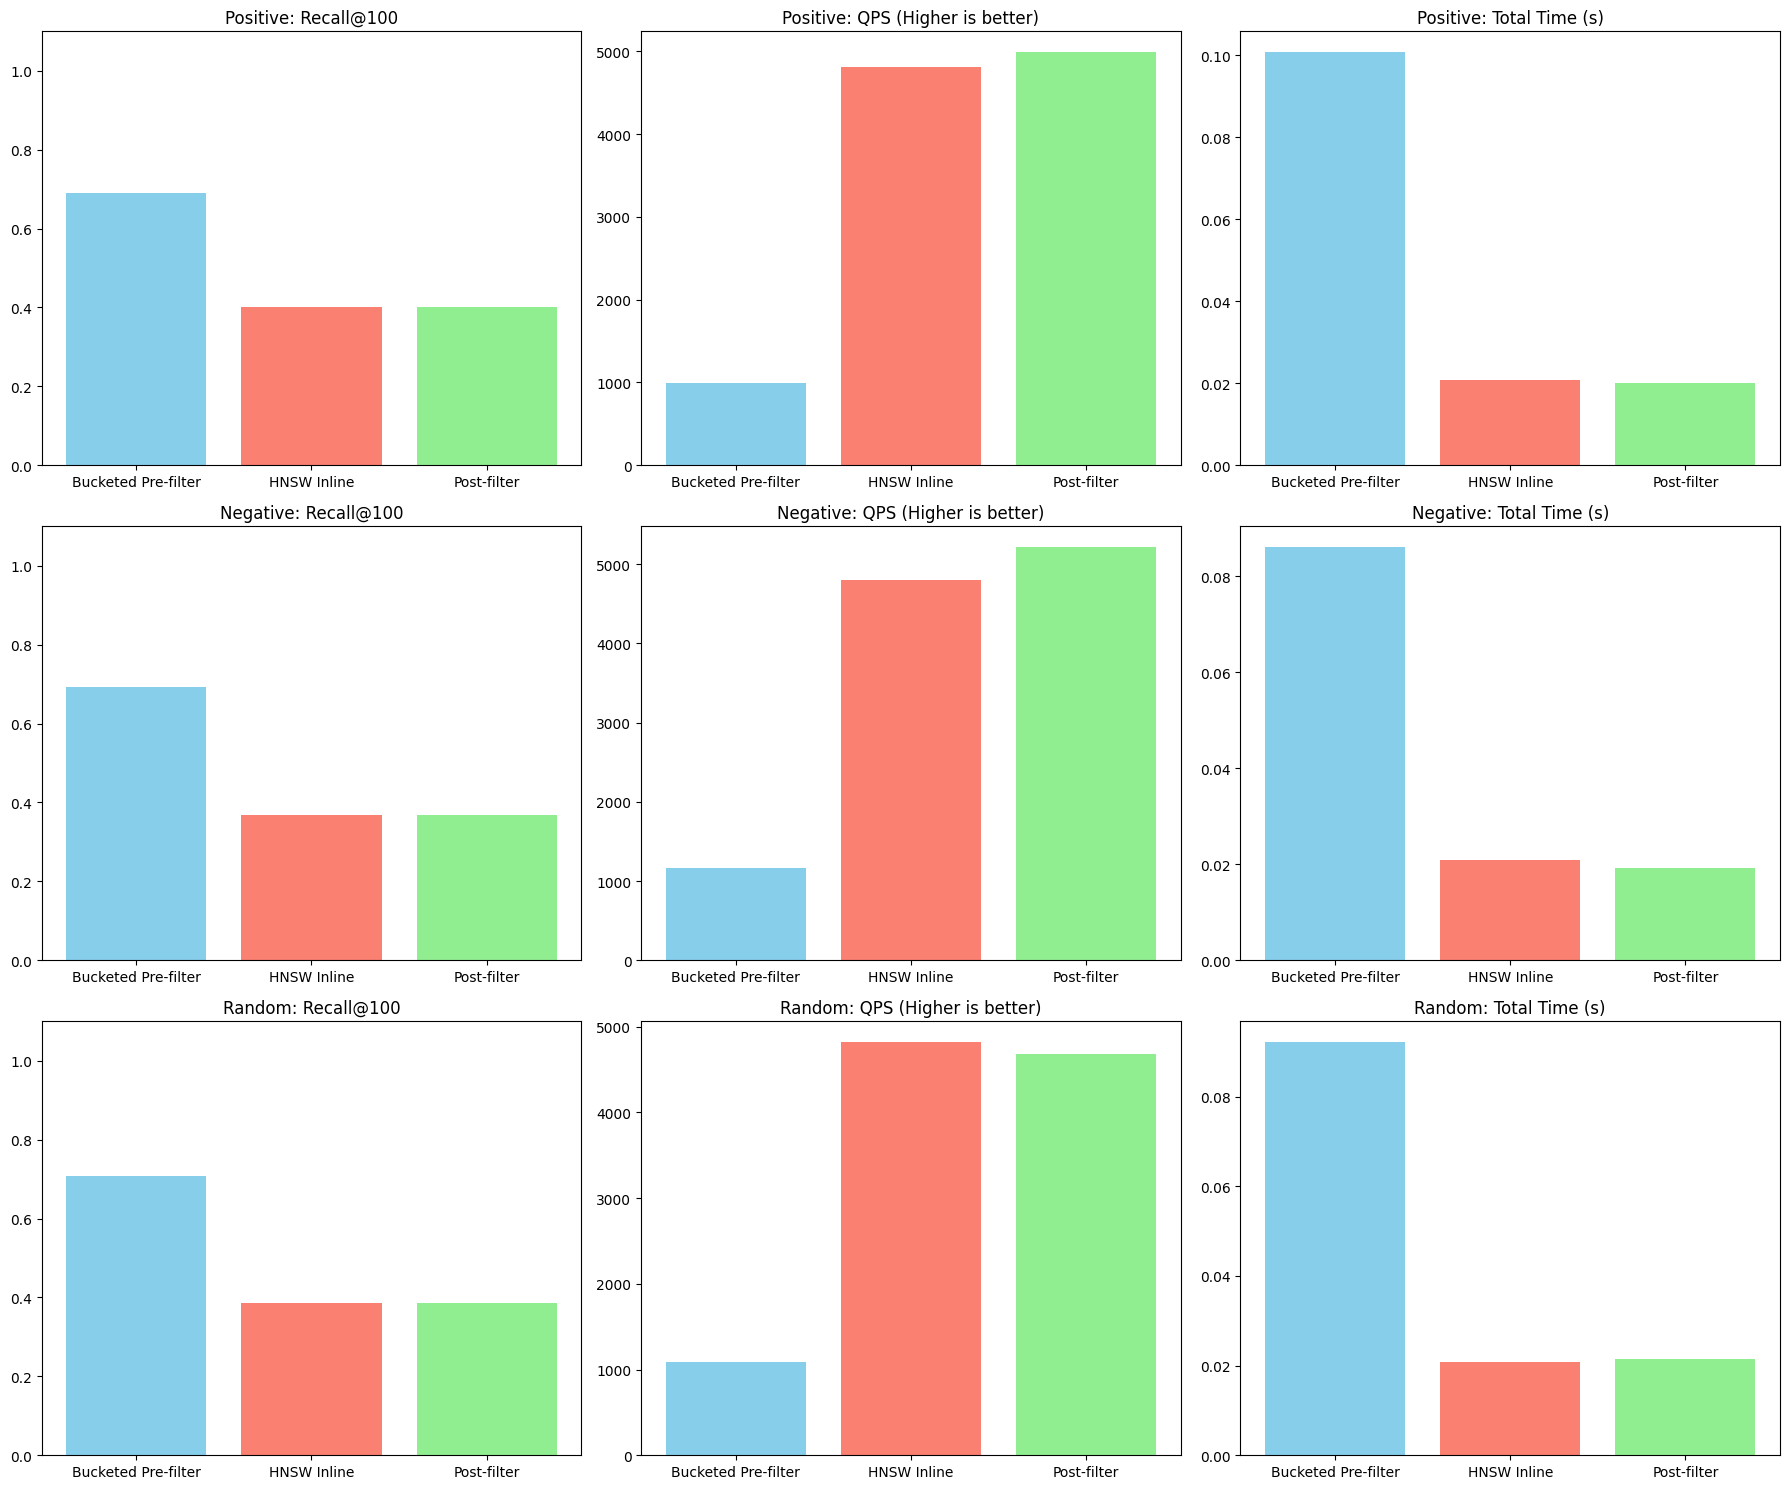

In [50]:
def plot_strategy_comparison(results_data):
    fig, axes = plt.subplots(len(results_data), 3, figsize=(18, 5 * len(results_data)))

    for i, res in enumerate(results_data):
        attr_name = res['attr_name']
        stats = res['data']
        names = [s['name'] for s in stats]
        recalls = [s['recall'] for s in stats]
        qps_vals = [s['qps'] for s in stats]
        times = [s['time'] for s in stats]

        # Recall Plot
        axes[i, 0].bar(names, recalls, color=['skyblue', 'salmon', 'lightgreen'])
        axes[i, 0].set_title(f"{attr_name}: Recall@100")
        axes[i, 0].set_ylim(0, 1.1)

        # QPS Plot
        axes[i, 1].bar(names, qps_vals, color=['skyblue', 'salmon', 'lightgreen'])
        axes[i, 1].set_title(f"{attr_name}: QPS (Higher is better)")

        # Time Plot
        axes[i, 2].bar(names, times, color=['skyblue', 'salmon', 'lightgreen'])
        axes[i, 2].set_title(f"{attr_name}: Total Time (s)")

    plt.tight_layout()
    plt.show()

plot_strategy_comparison(results_data)